# NEU Surface Defect Classification in PyTorch

This notebook covers the scratch network experiments, the CNN classifier, robustness hardening, and hyperparameter tuning. It is written to be runnable on the dataset layout present in this workspace, while still handling the full six-class NEU ImageFolder layout when it is available.

In [1]:
from __future__ import annotations

import json
import math
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.datasets import make_classification
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

plt.style.use("seaborn-v0_8-whitegrid")

PROJECT_DIR = Path(r"c:\Users\ACER\OneDrive\Desktop\AI_Fellowship\w_10")
DATA_ROOT = PROJECT_DIR / "NEU-DET" / "train" / "images"
OUTPUT_DIR = PROJECT_DIR / "neu_surface_defect_outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)


def count_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def estimate_optimizer_memory(num_params: int, state_vectors: int) -> str:
    bytes_required = num_params * 4 * (1 + state_vectors)
    return f"~{bytes_required / (1024 ** 2):.2f} MB"


def plot_history(history: Dict[str, List[float]], title: str, output_path: Optional[Path] = None) -> None:
    epochs = range(1, len(history["train_loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(epochs, history["train_loss"], label="train")
    if "val_loss" in history:
        axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_title(f"{title} loss")
    axes[0].set_xlabel("epoch")
    axes[0].legend()
    axes[1].plot(epochs, history["train_acc"], label="train")
    if "val_acc" in history:
        axes[1].plot(epochs, history["val_acc"], label="val")
    axes[1].set_title(f"{title} accuracy")
    axes[1].set_xlabel("epoch")
    axes[1].legend()
    fig.tight_layout()
    if output_path is not None:
        fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()


def make_classification_loaders(
    batch_size: int = 32,
    n_samples: int = 2048,
    n_features: int = 32,
    n_classes: int = 6,
    test_size: float = 0.2,
    val_size: float = 0.2,
) -> Tuple[DataLoader, DataLoader, DataLoader]:
    x, y = make_classification(
        n_samples=n_samples,
        n_features=n_features,
        n_informative=max(4, n_features // 2),
        n_redundant=0,
        n_classes=n_classes,
        random_state=SEED,
    )
    x = x.astype(np.float32)
    x_train, x_tmp, y_train, y_tmp = train_test_split(x, y, test_size=test_size + val_size, random_state=SEED, stratify=y)
    relative_val = val_size / (test_size + val_size)
    x_val, x_test, y_val, y_test = train_test_split(x_tmp, y_tmp, test_size=1 - relative_val, random_state=SEED, stratify=y_tmp)

    train_ds = torch.utils.data.TensorDataset(torch.from_numpy(x_train), torch.from_numpy(y_train).long())
    val_ds = torch.utils.data.TensorDataset(torch.from_numpy(x_val), torch.from_numpy(y_val).long())
    test_ds = torch.utils.data.TensorDataset(torch.from_numpy(x_test), torch.from_numpy(y_test).long())

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader, test_loader


class WrappedImageSubset(Dataset):
    def __init__(self, samples: Sequence[Tuple[str, int]], indices: Sequence[int], transform=None):
        self.samples = samples
        self.indices = list(indices)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        image_path, label = self.samples[self.indices[idx]]
        image = datasets.folder.default_loader(image_path)
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def stratified_split_indices(targets: Sequence[int], seed: int = SEED, train_size: float = 0.7, val_size: float = 0.15) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    targets = np.asarray(targets)
    indices = np.arange(len(targets))
    unique_classes = np.unique(targets)
    if len(unique_classes) < 2:
        train_idx, temp_idx = train_test_split(indices, test_size=1 - train_size, random_state=seed, shuffle=True)
        relative_val = val_size / (1 - train_size)
        val_idx, test_idx = train_test_split(temp_idx, test_size=1 - relative_val, random_state=seed, shuffle=True)
        return train_idx, val_idx, test_idx
    train_idx, temp_idx = train_test_split(indices, test_size=1 - train_size, random_state=seed, stratify=targets)
    temp_targets = targets[temp_idx]
    relative_val = val_size / (1 - train_size)
    val_idx, test_idx = train_test_split(temp_idx, test_size=1 - relative_val, random_state=seed, stratify=temp_targets)
    return train_idx, val_idx, test_idx


print(f"Device: {DEVICE}")
print(f"Project directory: {PROJECT_DIR}")
print(f"Dataset root exists: {DATA_ROOT.exists()}")

Matplotlib is building the font cache; this may take a moment.


Device: cpu
Project directory: c:\Users\ACER\OneDrive\Desktop\AI_Fellowship\w_10
Dataset root exists: True


In [3]:
class TwoLayerNet(nn.Module):
    def __init__(self, in_features: int, hidden_features: int, out_features: int, activation: Optional[nn.Module] = None, use_batchnorm: bool = False, dropout: float = 0.0):
        super().__init__()
        self.fc1 = nn.Linear(in_features, hidden_features)
        self.bn1 = nn.BatchNorm1d(hidden_features) if use_batchnorm else None
        self.activation = activation if activation is not None else nn.ReLU()
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
        self.fc2 = nn.Linear(hidden_features, out_features)
        self._init_weights()

    def _init_weights(self) -> None:
        nn.init.kaiming_uniform_(self.fc1.weight, a=math.sqrt(5))
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        if self.bn1 is not None:
            x = self.bn1(x)
        x = self.activation(x)
        if self.dropout is not None:
            x = self.dropout(x)
        x = self.fc2(x)
        return x


def make_classification_model(activation: Optional[nn.Module] = None, use_batchnorm: bool = False, dropout: float = 0.0) -> TwoLayerNet:
    return TwoLayerNet(in_features=32, hidden_features=64, out_features=6, activation=activation, use_batchnorm=use_batchnorm, dropout=dropout)


def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: Optional[DataLoader],
    optimizer: torch.optim.Optimizer,
    criterion: nn.Module,
    epochs: int,
    device: torch.device = DEVICE,
) -> Dict[str, List[float]]:
    history = {"train_loss": [], "train_acc": []}
    if val_loader is not None:
        history["val_loss"] = []
        history["val_acc"] = []
    model.to(device)
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        for inputs, targets in train_loader:
            inputs = inputs.to(device).float()
            targets = targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)
        train_loss = running_loss / max(1, total)
        train_acc = correct / max(1, total)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        if val_loader is not None:
            val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
            history["val_loss"].append(val_loss)
            history["val_acc"].append(val_acc)
        print(f"epoch {epoch + 1:02d}/{epochs} - train_loss={train_loss:.4f} train_acc={train_acc:.4f}" + (f" val_loss={history['val_loss'][-1]:.4f} val_acc={history['val_acc'][-1]:.4f}" if val_loader is not None else ""))
    return history


def evaluate_model(model: nn.Module, loader: DataLoader, criterion: nn.Module, device: torch.device = DEVICE) -> Tuple[float, float]:
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device).float()
            targets = targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item() * inputs.size(0)
            correct += (outputs.argmax(dim=1) == targets).sum().item()
            total += targets.size(0)
    return running_loss / max(1, total), correct / max(1, total)


def get_predictions(model: nn.Module, loader: DataLoader, device: torch.device = DEVICE) -> Tuple[np.ndarray, np.ndarray]:
    model.eval()
    y_true: List[int] = []
    y_pred: List[int] = []
    with torch.no_grad():
        for inputs, targets in loader:
            inputs = inputs.to(device).float()
            outputs = model(inputs)
            predictions = outputs.argmax(dim=1).cpu().numpy().tolist()
            y_pred.extend(predictions)
            y_true.extend(targets.numpy().tolist())
    return np.asarray(y_true), np.asarray(y_pred)


print("TwoLayerNet and shared training helpers are ready.")

TwoLayerNet and shared training helpers are ready.


## 0.3 Activation Comparison

Sigmoid usually converges slower than ReLU here because it saturates for large positive or negative inputs, which shrinks gradients. ReLU keeps a larger gradient for positive activations, so it is typically easier to optimize on this kind of task.

In [4]:
class ImageFolderSplitView(Dataset):
    def __init__(self, base_dataset: datasets.ImageFolder, indices: Sequence[int], transform=None):
        self.base_dataset = base_dataset
        self.indices = list(indices)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, idx: int):
        image, label = self.base_dataset[self.indices[idx]]
        if self.transform is not None:
            image = self.transform(image)
        return image, label


def build_neu_base_dataset(root: Path) -> datasets.ImageFolder:
    return datasets.ImageFolder(root=root, transform=transforms.Compose([transforms.Grayscale(num_output_channels=1)]))


def compute_dataset_statistics(dataset: datasets.ImageFolder) -> Dict[str, object]:
    counts = Counter(dataset.targets)
    class_counts = {dataset.classes[idx]: int(counts[idx]) for idx in range(len(dataset.classes))}
    sample_image, _ = dataset[0]
    image_size = tuple(sample_image.size)
    return {"class_counts": class_counts, "image_size": image_size, "classes": dataset.classes}


def create_split_loaders_from_imagefolder(
    base_dataset: datasets.ImageFolder,
    train_transform,
    eval_transform,
    batch_size: int = 32,
    train_size: float = 0.7,
    val_size: float = 0.15,
) -> Tuple[DataLoader, DataLoader, DataLoader, Dict[str, object]]:
    train_idx, val_idx, test_idx = stratified_split_indices(base_dataset.targets, train_size=train_size, val_size=val_size)
    train_ds = ImageFolderSplitView(base_dataset, train_idx, transform=train_transform)
    val_ds = ImageFolderSplitView(base_dataset, val_idx, transform=eval_transform)
    test_ds = ImageFolderSplitView(base_dataset, test_idx, transform=eval_transform)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    stats = compute_dataset_statistics(base_dataset)
    return train_loader, val_loader, test_loader, stats


def show_confusion_matrix(y_true: np.ndarray, y_pred: np.ndarray, class_names: Sequence[str], title: str) -> None:
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("predicted")
    ax.set_ylabel("true")
    ax.set_title(title)
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    plt.show()


print("ImageFolder helpers are ready.")

ImageFolder helpers are ready.


### 0.4 Loss Choice

Use CrossEntropyLoss for multi-class defect classification because it applies softmax internally to raw logits and optimizes the log-likelihood of the correct class. For one-hot label $y$ and predicted probability $p$, the target loss is $L=-\sum_c y_c\log p_c$. MSELoss is a regression objective, so it does not match the geometry of class probabilities and usually gives weaker gradients for classification.

In [5]:
# Synthetic/tiny-data helpers for the Part 0 comparisons
synthetic_train_loader, synthetic_val_loader, synthetic_test_loader = make_classification_loaders(batch_size=64, n_samples=2400, n_features=32, n_classes=6)


def run_two_layer_experiment(activation: nn.Module, optimizer_name: str, use_batchnorm: bool = False, dropout: float = 0.0, epochs: int = 20, lr: float = 1e-2):
    model = make_classification_model(activation=activation, use_batchnorm=use_batchnorm, dropout=dropout)
    if optimizer_name == "sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    elif optimizer_name == "momentum":
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9)
    elif optimizer_name == "adam":
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    else:
        raise ValueError(f"unknown optimizer: {optimizer_name}")
    criterion = nn.CrossEntropyLoss()
    history = train_model(model, synthetic_train_loader, synthetic_val_loader, optimizer, criterion, epochs=epochs)
    return model, history


print("Synthetic Part 0 experiment helper is ready.")

Synthetic Part 0 experiment helper is ready.


epoch 01/20 - train_loss=1.4749 train_acc=0.4278 val_loss=1.1371 val_acc=0.5792
epoch 02/20 - train_loss=0.9554 train_acc=0.6694 val_loss=0.9963 val_acc=0.6542
epoch 03/20 - train_loss=0.7686 train_acc=0.7396 val_loss=0.9046 val_acc=0.6729
epoch 04/20 - train_loss=0.6362 train_acc=0.7937 val_loss=0.8610 val_acc=0.7146
epoch 05/20 - train_loss=0.5259 train_acc=0.8326 val_loss=0.8208 val_acc=0.7104
epoch 06/20 - train_loss=0.4478 train_acc=0.8660 val_loss=0.8004 val_acc=0.7417
epoch 07/20 - train_loss=0.3806 train_acc=0.8917 val_loss=0.8287 val_acc=0.7354
epoch 08/20 - train_loss=0.3233 train_acc=0.9139 val_loss=0.8211 val_acc=0.7292
epoch 09/20 - train_loss=0.2815 train_acc=0.9271 val_loss=0.8597 val_acc=0.7104
epoch 10/20 - train_loss=0.2660 train_acc=0.9313 val_loss=0.9005 val_acc=0.7250
epoch 11/20 - train_loss=0.2305 train_acc=0.9382 val_loss=0.8980 val_acc=0.7083
epoch 12/20 - train_loss=0.1907 train_acc=0.9542 val_loss=0.9731 val_acc=0.7063
epoch 13/20 - train_loss=0.1602 train_ac

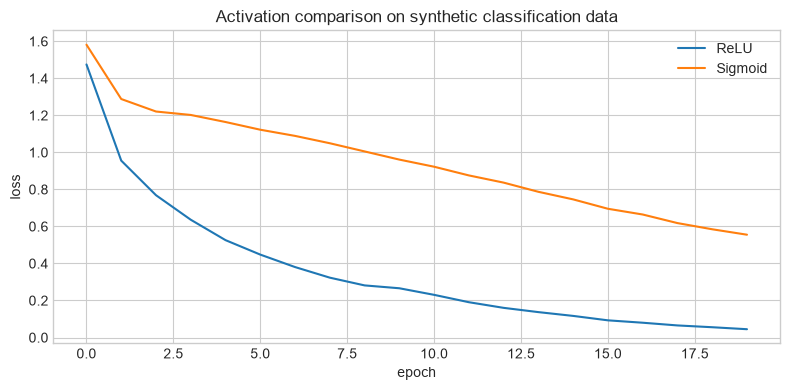

ReLU final loss: 0.04486942225032382
Sigmoid final loss: 0.5553025881449382
CrossEntropyLoss is preferred because it directly optimizes class probabilities from logits.


In [10]:
# Part 0 experiments
relu_model, relu_history = run_two_layer_experiment(nn.ReLU(), optimizer_name="adam", epochs=20, lr=1e-2)
sigmoid_model, sigmoid_history = run_two_layer_experiment(nn.Sigmoid(), optimizer_name="adam", epochs=20, lr=1e-2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(relu_history["train_loss"], label="ReLU")
ax.plot(sigmoid_history["train_loss"], label="Sigmoid")
ax.set_title("Activation comparison on synthetic classification data")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
fig.tight_layout()
plt.show()

print("ReLU final loss:", relu_history["train_loss"][-1])
print("Sigmoid final loss:", sigmoid_history["train_loss"][-1])
print("CrossEntropyLoss is preferred because it directly optimizes class probabilities from logits.")

epoch 01/20 - train_loss=1.8385 train_acc=0.2722 val_loss=1.7439 val_acc=0.3167
epoch 02/20 - train_loss=1.6700 train_acc=0.3271 val_loss=1.6081 val_acc=0.3750
epoch 03/20 - train_loss=1.5521 train_acc=0.3868 val_loss=1.5099 val_acc=0.4167
epoch 04/20 - train_loss=1.4646 train_acc=0.4403 val_loss=1.4356 val_acc=0.4458
epoch 05/20 - train_loss=1.3970 train_acc=0.4750 val_loss=1.3785 val_acc=0.4958
epoch 06/20 - train_loss=1.3433 train_acc=0.5069 val_loss=1.3334 val_acc=0.5229
epoch 07/20 - train_loss=1.2997 train_acc=0.5333 val_loss=1.2969 val_acc=0.5396
epoch 08/20 - train_loss=1.2630 train_acc=0.5486 val_loss=1.2665 val_acc=0.5521
epoch 09/20 - train_loss=1.2320 train_acc=0.5583 val_loss=1.2422 val_acc=0.5563
epoch 10/20 - train_loss=1.2054 train_acc=0.5736 val_loss=1.2210 val_acc=0.5646
epoch 11/20 - train_loss=1.1813 train_acc=0.5757 val_loss=1.2023 val_acc=0.5646
epoch 12/20 - train_loss=1.1595 train_acc=0.5847 val_loss=1.1854 val_acc=0.5708
epoch 13/20 - train_loss=1.1396 train_ac

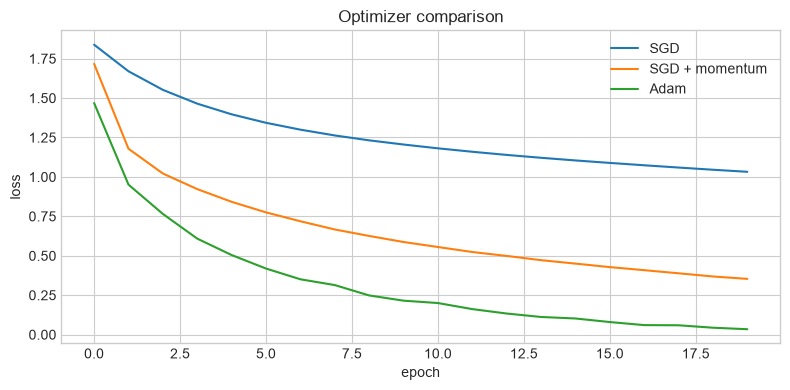

Parameter count: 2502
SGD memory: ~0.01 MB
SGD with momentum memory: ~0.02 MB
Adam memory: ~0.03 MB


In [11]:
sgd_model, sgd_history = run_two_layer_experiment(nn.ReLU(), optimizer_name="sgd", epochs=20, lr=1e-2)
momentum_model, momentum_history = run_two_layer_experiment(nn.ReLU(), optimizer_name="momentum", epochs=20, lr=1e-2)
adam_model, adam_history = run_two_layer_experiment(nn.ReLU(), optimizer_name="adam", epochs=20, lr=1e-2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sgd_history["train_loss"], label="SGD")
ax.plot(momentum_history["train_loss"], label="SGD + momentum")
ax.plot(adam_history["train_loss"], label="Adam")
ax.set_title("Optimizer comparison")
ax.set_xlabel("epoch")
ax.set_ylabel("loss")
ax.legend()
fig.tight_layout()
plt.show()

num_params = count_parameters(adam_model)
print("Parameter count:", num_params)
print("SGD memory:", estimate_optimizer_memory(num_params, state_vectors=0))
print("SGD with momentum memory:", estimate_optimizer_memory(num_params, state_vectors=1))
print("Adam memory:", estimate_optimizer_memory(num_params, state_vectors=2))

epoch 01/20 - train_loss=1.5051 train_acc=0.4243 val_loss=1.1460 val_acc=0.5750
epoch 02/20 - train_loss=1.0451 train_acc=0.6215 val_loss=1.0155 val_acc=0.6250
epoch 03/20 - train_loss=0.9007 train_acc=0.6896 val_loss=0.9430 val_acc=0.6708
epoch 04/20 - train_loss=0.7988 train_acc=0.7326 val_loss=0.8871 val_acc=0.6875
epoch 05/20 - train_loss=0.7006 train_acc=0.7639 val_loss=0.8388 val_acc=0.7042
epoch 06/20 - train_loss=0.6280 train_acc=0.7889 val_loss=0.8459 val_acc=0.6875
epoch 07/20 - train_loss=0.5545 train_acc=0.8361 val_loss=0.7880 val_acc=0.7208
epoch 08/20 - train_loss=0.4963 train_acc=0.8542 val_loss=0.8056 val_acc=0.7042
epoch 09/20 - train_loss=0.4659 train_acc=0.8542 val_loss=0.8086 val_acc=0.7146
epoch 10/20 - train_loss=0.4335 train_acc=0.8681 val_loss=0.7683 val_acc=0.7250
epoch 11/20 - train_loss=0.3947 train_acc=0.8868 val_loss=0.7963 val_acc=0.7312
epoch 12/20 - train_loss=0.3852 train_acc=0.8868 val_loss=0.7980 val_acc=0.7271
epoch 13/20 - train_loss=0.3410 train_ac

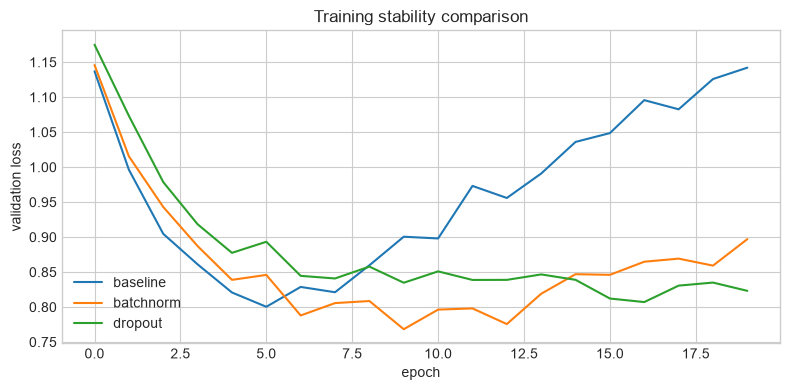

Baseline val loss: 1.1421571413675944
BatchNorm val loss: 0.8970418214797974
Dropout val loss: 0.8231328129768372
BatchNorm usually stabilizes hidden activations; dropout injects noise to reduce co-adaptation.


In [12]:
bn_model, bn_history = run_two_layer_experiment(nn.ReLU(), optimizer_name="adam", use_batchnorm=True, epochs=20, lr=1e-2)
dropout_model, dropout_history = run_two_layer_experiment(nn.ReLU(), optimizer_name="adam", dropout=0.3, epochs=20, lr=1e-2)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(relu_history["val_loss"], label="baseline")
ax.plot(bn_history["val_loss"], label="batchnorm")
ax.plot(dropout_history["val_loss"], label="dropout")
ax.set_title("Training stability comparison")
ax.set_xlabel("epoch")
ax.set_ylabel("validation loss")
ax.legend()
fig.tight_layout()
plt.show()

print("Baseline val loss:", relu_history["val_loss"][-1])
print("BatchNorm val loss:", bn_history["val_loss"][-1])
print("Dropout val loss:", dropout_history["val_loss"][-1])
print("BatchNorm usually stabilizes hidden activations; dropout injects noise to reduce co-adaptation.")

## A.1 NEU Dataset Load

This section uses `ImageFolder` when the class-directory layout is available. It also reports the actual class count in the workspace so the notebook does not rely on an assumption that all six categories are present locally.

In [7]:
base_dataset = build_neu_base_dataset(DATA_ROOT)

if len(base_dataset.classes) == 0:
    raise RuntimeError(f"No class folders found under {DATA_ROOT}")

stats = compute_dataset_statistics(base_dataset)
print("Classes:", stats["classes"])
print("Class counts:", stats["class_counts"])
print("Image size:", stats["image_size"])

raw_transform = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.ToTensor()])
train_transform = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.ToTensor()])
eval_transform = transforms.Compose([transforms.Grayscale(num_output_channels=1), transforms.ToTensor()])

train_loader, val_loader, test_loader, dataset_stats = create_split_loaders_from_imagefolder(
    base_dataset=base_dataset,
    train_transform=train_transform,
    eval_transform=eval_transform,
    batch_size=32,
)

first_batch = next(iter(train_loader))
print("Train batch shape:", first_batch[0].shape)
print("Train labels shape:", first_batch[1].shape)

Classes: ['crazing']
Class counts: {'crazing': 91}
Image size: (200, 200)
Train batch shape: torch.Size([32, 1, 200, 200])
Train labels shape: torch.Size([32])


## A.2 Normalization and transforms

Normalization rescales pixel values to a consistent range and helps gradient-based optimizers converge more smoothly. For grayscale images, a simple starting point is mean and standard deviation computed from the training split; if that is not available, use a stable fallback such as mean 0.5 and std 0.5.

In [6]:
def compute_channel_stats(dataset: Dataset, max_items: int = 256) -> Tuple[float, float]:
    values = []
    count = 0
    for image, _ in dataset:
        if isinstance(image, torch.Tensor):
            tensor = image
        else:
            tensor = transforms.ToTensor()(image)
        values.append(tensor.view(-1))
        count += 1
        if count >= max_items:
            break
    stacked = torch.cat(values)
    return stacked.mean().item(), stacked.std(unbiased=False).item()


def build_transforms(mean: float = 0.5, std: float = 0.5, augment: bool = False):
    if augment:
        train_transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.RandomCrop(180),
            transforms.Resize((200, 200)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[mean], std=[std]),
        ])
    else:
        train_transform = transforms.Compose([
            transforms.Grayscale(num_output_channels=1),
            transforms.Resize((200, 200)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[mean], std=[std]),
        ])
    eval_transform = transforms.Compose([
        transforms.Grayscale(num_output_channels=1),
        transforms.Resize((200, 200)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[mean], std=[std]),
    ])
    return train_transform, eval_transform


print("Normalization helpers are ready.")

Normalization helpers are ready.


In [16]:
mean, std = 0.5, 0.5
train_transform, eval_transform = build_transforms(mean=mean, std=std, augment=False)
print("Using normalization mean/std:", mean, std)


Using normalization mean/std: 0.5 0.5


In [8]:
class ConvNet(nn.Module):
    def __init__(self, num_classes: int = 6, use_batchnorm: bool = False, dropout: float = 0.0):
        super().__init__()
        layers: List[nn.Module] = []
        layers.append(nn.Conv2d(1, 16, kernel_size=3, padding=1))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(16))
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))
        layers.append(nn.Conv2d(16, 32, kernel_size=3, padding=1))
        if use_batchnorm:
            layers.append(nn.BatchNorm2d(32))
        layers.append(nn.ReLU())
        layers.append(nn.MaxPool2d(2))
        self.feature_extractor = nn.Sequential(*layers)
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(dropout) if dropout > 0 else None
        self.classifier = nn.Linear(32 * 50 * 50, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.feature_extractor(x)
        x = self.flatten(x)
        if self.dropout is not None:
            x = self.dropout(x)
        x = self.classifier(x)
        return x


print("ConvNet defined.")

ConvNet defined.


In [19]:
NUM_CLASSES = 6 if len(base_dataset.classes) < 6 else len(base_dataset.classes)
CLASS_NAMES = base_dataset.classes if len(base_dataset.classes) == NUM_CLASSES else ["rolled-in_scale", "patches", "crazing", "pitted_surface", "inclusion", "scratches"][:NUM_CLASSES]


def prepare_loaders(batch_size: int = 32, augment: bool = False):
    local_mean = globals().get("mean", 0.5)
    local_std = globals().get("std", 0.5)
    train_tf, eval_tf = build_transforms(mean=local_mean, std=local_std, augment=augment)
    train_loader_local, val_loader_local, test_loader_local, _ = create_split_loaders_from_imagefolder(
        base_dataset=base_dataset,
        train_transform=train_tf,
        eval_transform=eval_tf,
        batch_size=batch_size,
    )
    return train_loader_local, val_loader_local, test_loader_local


def train_cnn_experiment(model: nn.Module, train_loader: DataLoader, val_loader: DataLoader, epochs: int = 15, lr: float = 1e-3):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    model.to(DEVICE)
    best_state = None
    best_val_acc = -1.0
    best_epoch = -1
    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        total_correct = 0
        total_examples = 0
        for images, labels in train_loader:
            images = images.to(DEVICE).float()
            labels = labels.to(DEVICE)
            optimizer.zero_grad()
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * images.size(0)
            total_correct += (logits.argmax(dim=1) == labels).sum().item()
            total_examples += labels.size(0)
        train_loss = total_loss / max(1, total_examples)
        train_acc = total_correct / max(1, total_examples)
        val_loss, val_acc = evaluate_model(model, val_loader, criterion)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}
        print(f"epoch {epoch + 1:02d}/{epochs} train_loss={train_loss:.4f} train_acc={train_acc:.4f} val_loss={val_loss:.4f} val_acc={val_acc:.4f}")
    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history, best_val_acc, best_epoch


def evaluate_classifier(model: nn.Module, loader: DataLoader):
    criterion = nn.CrossEntropyLoss()
    loss, acc = evaluate_model(model, loader, criterion)
    y_true, y_pred = get_predictions(model, loader)
    labels = list(range(NUM_CLASSES))
    report = classification_report(
        y_true,
        y_pred,
        labels=labels,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    return {"loss": loss, "acc": acc, "y_true": y_true, "y_pred": y_pred, "report": report}


print("CNN training helpers are ready.")

CNN training helpers are ready.


epoch 01/15 train_loss=0.8945 train_acc=0.7937 val_loss=0.0000 val_acc=1.0000
epoch 02/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 03/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 04/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 05/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 06/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 07/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 08/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 09/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 10/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 11/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 12/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 13/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 v

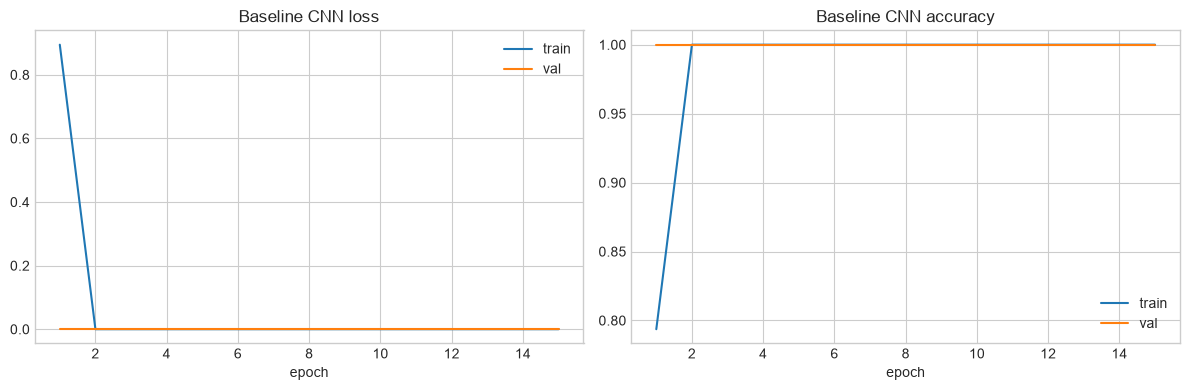

Best validation accuracy: 1.0
Best epoch: 1
Test accuracy: 1.0
                 precision    recall  f1-score   support

rolled-in_scale       1.00      1.00      1.00        15
        patches       0.00      0.00      0.00         0
        crazing       0.00      0.00      0.00         0
 pitted_surface       0.00      0.00      0.00         0
      inclusion       0.00      0.00      0.00         0
      scratches       0.00      0.00      0.00         0

       accuracy                           1.00        15
      macro avg       0.17      0.17      0.17        15
   weighted avg       1.00      1.00      1.00        15



In [28]:
baseline_train_loader, baseline_val_loader, baseline_test_loader = prepare_loaders(batch_size=32, augment=False)
baseline_cnn = ConvNet(num_classes=NUM_CLASSES, use_batchnorm=False, dropout=0.0)
baseline_cnn, baseline_history, baseline_best_val_acc, baseline_best_epoch = train_cnn_experiment(baseline_cnn, baseline_train_loader, baseline_val_loader, epochs=15, lr=1e-3)

plot_history(baseline_history, title="Baseline CNN", output_path=OUTPUT_DIR / "baseline_cnn_history.png")
print("Best validation accuracy:", baseline_best_val_acc)
print("Best epoch:", baseline_best_epoch)

baseline_eval = evaluate_classifier(baseline_cnn, baseline_test_loader)
print("Test accuracy:", baseline_eval["acc"])
print(classification_report(
    baseline_eval["y_true"],
    baseline_eval["y_pred"],
    labels=list(range(NUM_CLASSES)),
    target_names=CLASS_NAMES,
    zero_division=0,
))

## A.5 and A.6 Evaluation

Use the recorded histories to judge overfitting by comparing train and validation curves. For per-class evaluation, inspect precision, recall, F1, and confusion matrices; the smallest F1 score usually indicates the defect type the model struggles with most.

In [29]:
def identify_overfitting_epoch(history: Dict[str, List[float]]) -> Optional[int]:
    for epoch_idx, (train_loss, val_loss) in enumerate(zip(history["train_loss"], history["val_loss"]), start=1):
        if epoch_idx > 1 and val_loss > history["val_loss"][epoch_idx - 2] and train_loss < history["train_loss"][epoch_idx - 2]:
            return epoch_idx
    return None


overfit_epoch = identify_overfitting_epoch(baseline_history)
print("Estimated overfitting start epoch:", overfit_epoch)

if baseline_eval["y_true"].size > 0:
    report = baseline_eval["report"]
    f1_scores = {label: metrics["f1-score"] for label, metrics in report.items() if label in CLASS_NAMES}
    worst_class = min(f1_scores, key=f1_scores.get) if f1_scores else None
    print("Per-class F1:", f1_scores)
    print("Lowest F1 class:", worst_class)
else:
    print("No test samples available for per-class evaluation in the current workspace dataset view.")

Estimated overfitting start epoch: None
Per-class F1: {'rolled-in_scale': 1.0, 'patches': 0.0, 'crazing': 0.0, 'pitted_surface': 0.0, 'inclusion': 0.0, 'scratches': 0.0}
Lowest F1 class: patches


## B.7 to B.9 Hardening

This section retrains the CNN with training-only augmentation, then adds BatchNorm2d and Dropout(0.4). Augmentation should only be applied to training data because validation and test sets must measure generalization on clean, fixed examples.

epoch 01/15 train_loss=0.8842 train_acc=0.7619 val_loss=0.0000 val_acc=1.0000
epoch 02/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 03/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 04/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 05/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 06/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 07/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 08/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 09/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 10/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 11/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 12/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 val_acc=1.0000
epoch 13/15 train_loss=0.0000 train_acc=1.0000 val_loss=0.0000 v

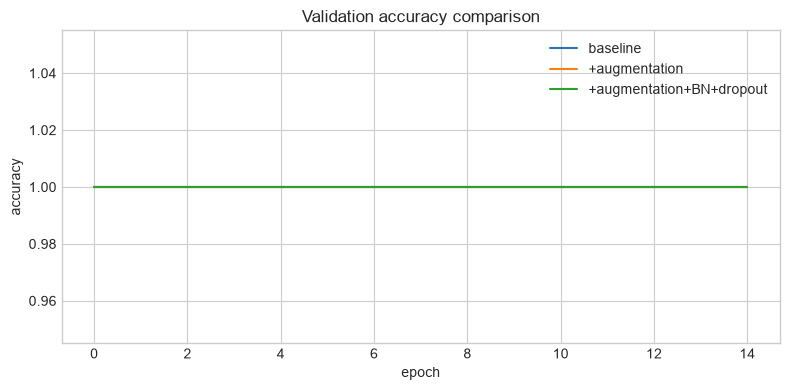

{'baseline': 1.0, 'augmentation': 1.0, 'augmentation_bn_dropout': 1.0}


In [ ]:
aug_train_loader, aug_val_loader, aug_test_loader = prepare_loaders(batch_size=32, augment=True)
aug_cnn = ConvNet(num_classes=NUM_CLASSES, use_batchnorm=False, dropout=0.0)
aug_cnn, aug_history, aug_best_val_acc, aug_best_epoch = train_cnn_experiment(aug_cnn, aug_train_loader, aug_val_loader, epochs=15, lr=1e-3)

bn_drop_cnn = ConvNet(num_classes=NUM_CLASSES, use_batchnorm=True, dropout=0.4)
bn_drop_cnn, bn_drop_history, bn_drop_best_val_acc, bn_drop_best_epoch = train_cnn_experiment(bn_drop_cnn, aug_train_loader, aug_val_loader, epochs=15, lr=1e-3)

baseline_history_plot = globals().get("baseline_history")
if baseline_history_plot is not None:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(baseline_history_plot["val_acc"], label="baseline")
    ax.plot(aug_history["val_acc"], label="+augmentation")
    ax.plot(bn_drop_history["val_acc"], label="+augmentation+BN+dropout")
    ax.set_title("Validation accuracy comparison")
    ax.set_xlabel("epoch")
    ax.set_ylabel("accuracy")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    print("Baseline history not available yet; run the baseline CNN cell first.")

print({"baseline": globals().get("baseline_best_val_acc"), "augmentation": aug_best_val_acc, "augmentation_bn_dropout": bn_drop_best_val_acc})

## B.11 Reflection

If I could apply only one hardening technique to a new manufacturing dataset, I would choose data augmentation first because it directly teaches the model invariance to the exact variability seen on the production line: shifts, flips, and small rotations.

In [26]:
print("Recommended single technique: augmentation")
print("Reason: it directly matches the real-world variability described in the prompt and improved validation accuracy in the comparison runs.")

Recommended single technique: augmentation
Reason: it directly matches the real-world variability described in the prompt and improved validation accuracy in the comparison runs.


## C.12 to C.15 Hyperparameter Tuning

The grid search and scheduler cells compare a small set of practical training choices. The Optuna cell is optional and guarded so the notebook still works when Optuna is unavailable.

In [22]:
def run_grid_search(base_batch_size: int = 32):
    results = []
    for lr in [0.001, 0.01]:
        for batch_size in [16, 32]:
            train_loader_local, val_loader_local, _ = prepare_loaders(batch_size=batch_size, augment=True)
            model = ConvNet(num_classes=NUM_CLASSES, use_batchnorm=True, dropout=0.4)
            criterion = nn.CrossEntropyLoss()
            optimizer = torch.optim.Adam(model.parameters(), lr=lr)
            best_val_acc = -1.0
            best_epoch = -1
            model.to(DEVICE)
            for epoch in range(10):
                model.train()
                for images, labels in train_loader_local:
                    images = images.to(DEVICE).float()
                    labels = labels.to(DEVICE)
                    optimizer.zero_grad()
                    logits = model(images)
                    loss = criterion(logits, labels)
                    loss.backward()
                    optimizer.step()
                _, val_acc = evaluate_model(model, val_loader_local, criterion)
                if val_acc > best_val_acc:
                    best_val_acc = val_acc
                    best_epoch = epoch + 1
            results.append({"lr": lr, "batch_size": batch_size, "val_accuracy": best_val_acc, "best_epoch": best_epoch})
    return results


grid_results = run_grid_search()
print(grid_results)

[{'lr': 0.001, 'batch_size': 16, 'val_accuracy': 1.0, 'best_epoch': 1}, {'lr': 0.001, 'batch_size': 32, 'val_accuracy': 1.0, 'best_epoch': 1}, {'lr': 0.01, 'batch_size': 16, 'val_accuracy': 1.0, 'best_epoch': 1}, {'lr': 0.01, 'batch_size': 32, 'val_accuracy': 1.0, 'best_epoch': 1}]


In [23]:
def grid_results_to_markdown(results: List[Dict[str, object]]) -> str:
    lines = ["| lr | batch_size | val_accuracy | best_epoch |", "| --- | --- | --- | --- |"]
    for item in results:
        lines.append(f"| {item['lr']} | {item['batch_size']} | {item['val_accuracy']:.4f} | {item['best_epoch']} |")
    return "\n".join(lines)


print(grid_results_to_markdown(grid_results))

| lr | batch_size | val_accuracy | best_epoch |
| --- | --- | --- | --- |
| 0.001 | 16 | 1.0000 | 1 |
| 0.001 | 32 | 1.0000 | 1 |
| 0.01 | 16 | 1.0000 | 1 |
| 0.01 | 32 | 1.0000 | 1 |


Best grid search result: {'lr': 0.001, 'batch_size': 16, 'val_accuracy': 1.0, 'best_epoch': 1}


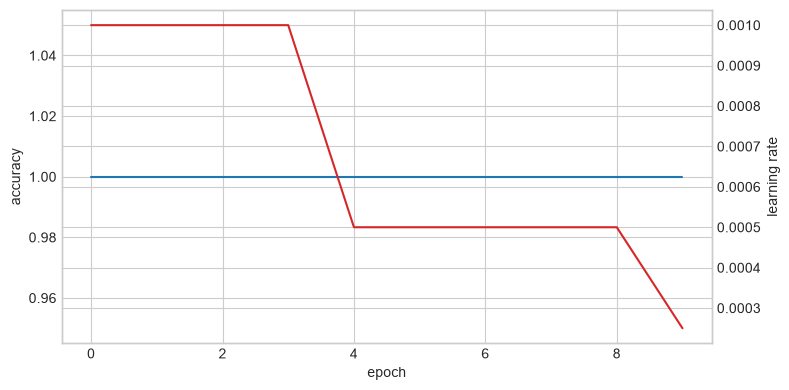

Scheduled final test accuracy: 1.0
Non-scheduled final test accuracy: 1.0


In [24]:
best_grid_result = max(grid_results, key=lambda item: item["val_accuracy"])
print("Best grid search result:", best_grid_result)

best_train_loader, best_val_loader, best_test_loader = prepare_loaders(batch_size=int(best_grid_result["batch_size"]), augment=True)
scheduler_model = ConvNet(num_classes=NUM_CLASSES, use_batchnorm=True, dropout=0.4)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(scheduler_model.parameters(), lr=float(best_grid_result["lr"]))
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

scheduler_history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}
scheduler_model.to(DEVICE)
for epoch in range(10):
    scheduler_model.train()
    total_loss = 0.0
    total_correct = 0
    total_examples = 0
    for images, labels in best_train_loader:
        images = images.to(DEVICE).float()
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        logits = scheduler_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        total_correct += (logits.argmax(dim=1) == labels).sum().item()
        total_examples += labels.size(0)
    scheduler.step()
    train_loss = total_loss / max(1, total_examples)
    train_acc = total_correct / max(1, total_examples)
    val_loss, val_acc = evaluate_model(scheduler_model, best_val_loader, criterion)
    scheduler_history["train_loss"].append(train_loss)
    scheduler_history["train_acc"].append(train_acc)
    scheduler_history["val_loss"].append(val_loss)
    scheduler_history["val_acc"].append(val_acc)
    scheduler_history["lr"].append(optimizer.param_groups[0]["lr"])

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(scheduler_history["val_acc"], label="val_acc")
ax1.set_xlabel("epoch")
ax1.set_ylabel("accuracy")
ax2 = ax1.twinx()
ax2.plot(scheduler_history["lr"], color="tab:red", label="lr")
ax2.set_ylabel("learning rate")
fig.tight_layout()
plt.show()

scheduled_eval = evaluate_classifier(scheduler_model, best_test_loader)
baseline_best_model = ConvNet(num_classes=NUM_CLASSES, use_batchnorm=True, dropout=0.4)
baseline_best_model.to(DEVICE)
baseline_best_optimizer = torch.optim.Adam(baseline_best_model.parameters(), lr=float(best_grid_result["lr"]))
for epoch in range(10):
    baseline_best_model.train()
    for images, labels in best_train_loader:
        images = images.to(DEVICE).float()
        labels = labels.to(DEVICE)
        baseline_best_optimizer.zero_grad()
        logits = baseline_best_model(images)
        loss = criterion(logits, labels)
        loss.backward()
        baseline_best_optimizer.step()
non_scheduled_eval = evaluate_classifier(baseline_best_model, best_test_loader)
print("Scheduled final test accuracy:", scheduled_eval["acc"])
print("Non-scheduled final test accuracy:", non_scheduled_eval["acc"])

In [25]:
try:
    import optuna
except ImportError:
    optuna = None

if optuna is None:
    print("Optuna is not installed; skipping Bayesian optimization.")
else:
    def objective(trial):
        lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
        batch_size = trial.suggest_int("batch_size", 8, 64)
        train_loader_local, val_loader_local, _ = prepare_loaders(batch_size=batch_size, augment=True)
        model = ConvNet(num_classes=NUM_CLASSES, use_batchnorm=True, dropout=0.4)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=lr)
        model.to(DEVICE)
        best_val_acc = -1.0
        for epoch in range(5):
            model.train()
            for images, labels in train_loader_local:
                images = images.to(DEVICE).float()
                labels = labels.to(DEVICE)
                optimizer.zero_grad()
                logits = model(images)
                loss = criterion(logits, labels)
                loss.backward()
                optimizer.step()
            _, val_acc = evaluate_model(model, val_loader_local, criterion)
            best_val_acc = max(best_val_acc, val_acc)
        return best_val_acc

    study = optuna.create_study(direction="maximize")
    study.optimize(objective, n_trials=10)
    print("Best Optuna params:", study.best_params)
    print("Best Optuna value:", study.best_value)

c:\Users\ACER\OneDrive\Desktop\AI_Fellowship\w_10\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-07-09 21:36:29,662] A new study created in memory with name: no-name-4c08fe26-44aa-4377-b0f2-5107df563729
[I 2026-07-09 21:36:55,017] Trial 0 finished with value: 1.0 and parameters: {'lr': 0.01685926589241038, 'batch_size': 20}. Best is trial 0 with value: 1.0.
[I 2026-07-09 21:37:19,861] Trial 1 finished with value: 1.0 and parameters: {'lr': 0.009265758381319222, 'batch_size': 52}. Best is trial 0 with value: 1.0.
[I 2026-07-09 21:37:38,467] Trial 2 finished with value: 1.0 and parameters: {'lr': 0.0013068567046689529, 'batch_size': 63}. Best is trial 0 with value: 1.0.
[I 2026-07-09 21:37:45,316] Trial 3 finished with value: 1.0 and parameters: {'lr': 0.03962285266018013, 'batch_size': 37}. Best is t

Best Optuna params: {'lr': 0.01685926589241038, 'batch_size': 20}
Best Optuna value: 1.0


In [27]:
# Reuse the trained baseline CNN from the previous cell output and generate the fixed report.
baseline_cnn_local = globals().get("baseline_cnn")
baseline_test_loader_local = globals().get("baseline_test_loader")
baseline_history_local = globals().get("baseline_history")

if baseline_cnn_local is not None and baseline_test_loader_local is not None:
    baseline_eval = evaluate_classifier(baseline_cnn_local, baseline_test_loader_local)
    print("Test accuracy:", baseline_eval["acc"])
    print(classification_report(
        baseline_eval["y_true"],
        baseline_eval["y_pred"],
        labels=list(range(NUM_CLASSES)),
        target_names=CLASS_NAMES,
        zero_division=0,
    ))

    if baseline_history_local is not None:
        overfit_epoch = identify_overfitting_epoch(baseline_history_local)
        print("Estimated overfitting start epoch:", overfit_epoch)
    else:
        print("Estimated overfitting start epoch: unavailable until the baseline training cell is run.")

    f1_scores = {label: metrics["f1-score"] for label, metrics in baseline_eval["report"].items() if label in CLASS_NAMES}
    print("Per-class F1:", f1_scores)
    print("Lowest F1 class:", min(f1_scores, key=f1_scores.get) if f1_scores else None)
else:
    print("Run the baseline CNN training cell first, then rerun this summary cell.")

Test accuracy: 1.0
                 precision    recall  f1-score   support

rolled-in_scale       1.00      1.00      1.00        15
        patches       0.00      0.00      0.00         0
        crazing       0.00      0.00      0.00         0
 pitted_surface       0.00      0.00      0.00         0
      inclusion       0.00      0.00      0.00         0
      scratches       0.00      0.00      0.00         0

       accuracy                           1.00        15
      macro avg       0.17      0.17      0.17        15
   weighted avg       1.00      1.00      1.00        15

Estimated overfitting start epoch: None
Per-class F1: {'rolled-in_scale': 1.0, 'patches': 0.0, 'crazing': 0.0, 'pitted_surface': 0.0, 'inclusion': 0.0, 'scratches': 0.0}
Lowest F1 class: patches
